# Baseline Model
Use sktime's NaiveForecaster to create a initial baseline for the demand forecasting model.

# 0. Imports

In [93]:
# To be able to import utils' functions
import sys
from pathlib import Path

parent_dir = str(Path.cwd().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [94]:
# Data Analysis
import numpy as np

import pandas as pd

# Utils
from utils.data_loader_utils import load_sales_data

from tqdm import tqdm

import os

# Model
from sktime.forecasting.naive import NaiveForecaster

from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import root_mean_squared_log_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# 1. Load Data

In [95]:
df_sales = load_sales_data(
    sales_data_path='../data/train.csv',
    add_demand_classification=True
)

df_sales = df_sales[df_sales['date'] >= '2017-04-15'] # Filter out data before 2017 to focus on more recent trends

display(df_sales)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
2781702,2017-04-15,1,AUTOMOTIVE,3.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic
2781703,2017-04-15,1,BABY CARE,0.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,intermittent
2781704,2017-04-15,1,BEAUTY,1.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,smooth
2781705,2017-04-15,1,BEVERAGES,1946.000,13,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,smooth
2781706,2017-04-15,1,BOOKS,0.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,intermittent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000885,2017-08-15,9,PRODUCE,2419.729,148,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,lumpy


In [96]:
# Check demand_type distribution
df_sales['granularity_pair'] = list(zip(df_sales["store_nbr"], df_sales["family"]))

print(df_sales.groupby('demand_type')['granularity_pair'].nunique().sort_values(ascending=False))

df_sales.drop(columns=['granularity_pair'], inplace=True)

demand_type
smooth          944
erratic         374
intermittent    280
lumpy           184
Name: granularity_pair, dtype: int64


In [97]:
# Get granularity with the most sales
display(
     df_sales
    .groupby(['store_nbr', 'family'])['sales']
    .sum()
    .reset_index()
    .sort_values(by='sales', ascending=False)
    .head(n=30)
)

,store_nbr,family,sales
1464,45,GROCERY I,1.438902e+06
1530,47,GROCERY I,1.352396e+06
1422,44,BEVERAGES,1.315946e+06
1497,46,GROCERY I,1.309076e+06
1431,44,GROCERY I,1.307104e+06
1449,44,PRODUCE,1.227505e+06
1455,45,BEVERAGES,1.219718e+06
1521,47,BEVERAGES,1.160675e+06
69,3,BEVERAGES,1.128807e+06
1563,48,GROCERY I,1.086235e+06


In [98]:
# Select granularity with a lot of sales
df_subset = df_sales[(df_sales['store_nbr'] == 45) & (df_sales['family'] == 'GROCERY I')].sort_values(by='date')

display(df_subset)
plt.show()

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
2783001,2017-04-15,45,GROCERY I,13064.0,106,52.905000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2784783,2017-04-16,45,GROCERY I,17177.0,112,52.762500,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2786565,2017-04-17,45,GROCERY I,10326.0,100,52.620000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2788347,2017-04-18,45,GROCERY I,9012.0,109,52.460000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2790129,2017-04-19,45,GROCERY I,9549.0,133,50.490000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993277,2017-08-11,45,GROCERY I,11088.0,40,48.810000,Quito,Pichincha,A,11,Traslado Primer Grito de Independencia,N/A,N/A,smooth
2995059,2017-08-12,45,GROCERY I,9917.0,39,48.403333,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2996841,2017-08-13,45,GROCERY I,12723.0,38,47.996667,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2998623,2017-08-14,45,GROCERY I,9665.0,39,47.590000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth


# 2. Run Model for All Granularities

In [99]:
# Helper method to plot last fold results
def plot_last_fold(df_sales: pd.DataFrame, fold_data: dict,
                   date_col: str = 'date') -> None:
    """
    Plot results from the last fold of a cross-validation.
    
    Args:
        df_sales: Original dataframe with dates
        fold_data: Dictionary with last fold data
        date_col: name of the date_column. Defaults
            to 'date'.
    """
    
    train_idx = fold_data['train_idx']
    test_idx = fold_data['test_idx']
    
    # Get last 90 days of training for visualization
    train_plot_start = max(0, len(train_idx) - 90)
    train_plot_indices = train_idx[train_plot_start:]
    
    # Extract data
    dates_train = df_sales[date_col].iloc[train_plot_indices].values
    y_train = fold_data['y_train'].iloc[train_plot_start:].values \
        if isinstance(fold_data['y_train'], pd.Series) else fold_data['y_train']
    fitted = fold_data['fitted_values'].iloc[train_plot_start:].values \
        if isinstance(fold_data['fitted_values'], pd.Series) else fold_data['fitted_values']
    
    dates_test = df_sales[date_col].iloc[test_idx].values 
    y_test = fold_data['y_test'].values if isinstance(fold_data['y_test'], pd.Series) else fold_data['y_test']
    forecast = fold_data['forecast'].values if isinstance(fold_data['forecast'], pd.Series) else fold_data['forecast']
    
    # Create plot
    plt.figure(figsize=(14, 6))
    
    # Train data
    sns.lineplot(
        x=dates_train,
        y=y_train,
        label='Train (Real)',
        alpha=0.7,
        color='blue'
    )
    
    # Fitted values
    sns.lineplot(
        x=dates_train,
        y=fitted,
        label='Fitted Values',
        linestyle='--',
        color='blue',
        alpha=0.5
    )
    
    # Test data
    sns.lineplot(
        x=dates_test,
        y=y_test,
        label='Test (Real)',
        alpha=0.7,
        color='green',
        linewidth=2
    )
    
    # Forecast
    sns.lineplot(
        x=dates_test,
        y=forecast,
        label='Forecast',
        linestyle='--',
        color='red',
        linewidth=2
    )
        
    plt.title("Real vs Predicted (Last Fold)")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Running 5 folds...

Fold 0:
  Train: 2017-04-15 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 0.2874
  Test RMSLE: 0.3431

Fold 1:
  Train: 2017-04-15 to 2017-06-16
  Test:  2017-06-17 to 2017-07-01
  Train RMSLE: 0.2957
  Test RMSLE: 0.3081

Fold 2:
  Train: 2017-04-15 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.5666
  Test RMSLE: 0.5590

Fold 3:
  Train: 2017-04-15 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.4035
  Test RMSLE: 0.3875

Fold 4:
  Train: 2017-04-15 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.2594
  Test RMSLE: 0.1896

Cross-Validation Results:
   Train RMSLE Mean: 0.3625
   Train RMSLE Std:  0.1132
   Train Min RMSLE:  0.2594
   Train Max RMSLE:  0.5666
   Test RMSLE Mean: 0.3575
   Test RMSLE Std:  0.1203
   Test Min RMSLE:  0.1896
   Test Max RMSLE:  0.5590


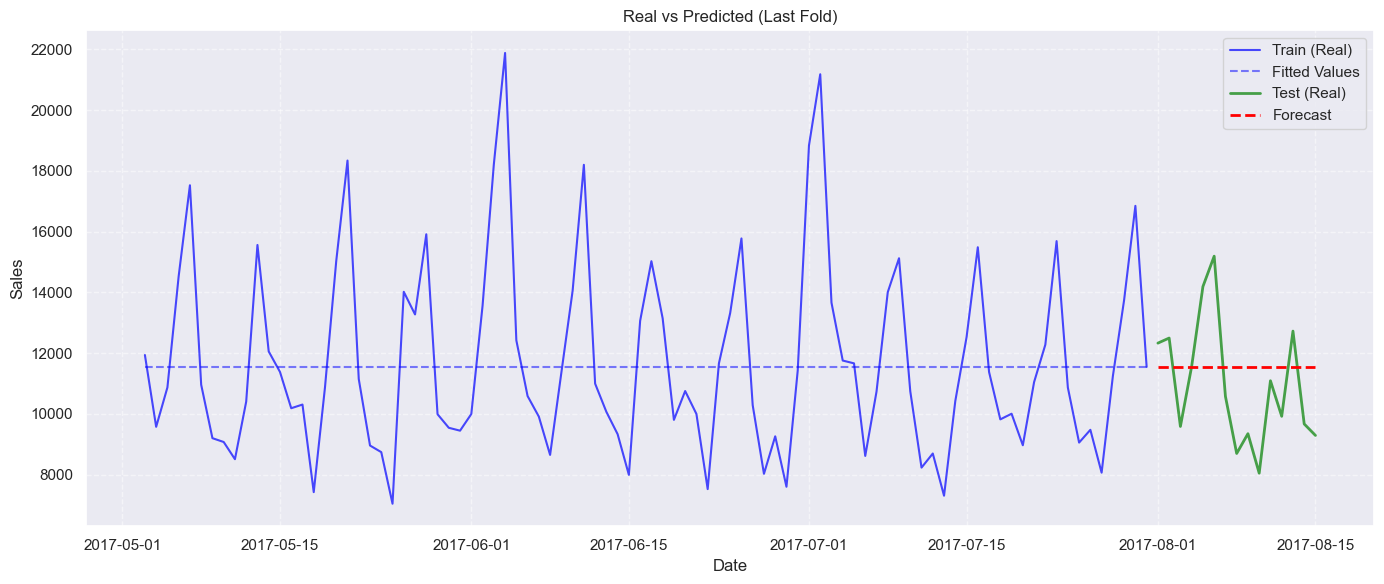

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,45,GROCERY I,0.362527,0.113212,0.259378,0.56662,0.357459,0.120259,0.189627,0.55896,1438902.0,123,smooth,5


In [100]:
def train_and_evaluate_simple_forecaster(df_sales: pd.DataFrame, n_folds: int = 5,
                                         test_size: int = 15, skew_threshold: float | None = None,
                                         plot_results: bool = False, verbose: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a SimpleForecaster model
    for a given sales time series using
    Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe containing 'date' and 'sales'.
        n_folds (int, optional): amount of CV's n folds. Defaults to 5.
        test_size (int, optional): test set's size. Defaults to 15.
        skew_threshold (float | None): If not None and skewness exceeds this value,
            log transformation is applied to the target.
        plot_results (bool): Whether to plot real vs predicted values (last fold).
        verbose (bool): Whether to print model summary and performance.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    
    df_sales = df_sales.sort_values("date").copy()
    target_col = "sales"

    # Apply log transformation if needed
    if skew_threshold is not None and abs(df_sales["sales"].skew()) > skew_threshold:
        df_sales["sales_log"] = np.log1p(df_sales["sales"])
        target_col = "sales_log"

    y = df_sales[target_col]

    test_cv_metrics = []
    train_cv_metrics = []
    tscv = TimeSeriesSplit(n_splits=n_folds, test_size=test_size)

    # Variables to store last fold for plotting
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(y)} folds...\n")

    for i, (train_index, test_index) in enumerate(tscv.split(y)):
        # Train model
        model = NaiveForecaster(
            strategy='mean',
            window_length=7
        )

        fitted = model.fit(y.iloc[train_index])

        # Predict
        y_test_fold = y.iloc[test_index]
        y_train_fold = y.iloc[train_index]
        
        forecast = fitted.predict(fh=[j for j in range(1, len(test_index) + 1)])

        fitted_values = fitted.predict(fh=[j for j in range(1, len(train_index) + 1)])

        # Remove negative values, if any
        test_forecast = [forecast if forecast >= 0 else 0 for forecast in forecast]
        fitted_values = [val if val >= 0 else 0 for val in fitted_values]

        # Calculate metrics
        if 'log' in target_col:
            fitted_values_real = np.expm1(fitted_values)
            y_train_real = np.expm1(y_train_fold)

            y_test_real = np.expm1(y_test_fold)
            forecast_real = np.expm1(test_forecast)
        else:
            fitted_values_real = fitted_values
            y_train_real = y_train_fold

            y_test_real = y_test_fold
            forecast_real = test_forecast

        train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
        test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

        train_cv_metrics.append(train_rmsle)
        test_cv_metrics.append(test_rmsle)

        if verbose:
            train_dates = df_sales['date'].iloc[train_index]
            test_dates = df_sales['date'].iloc[test_index]
            print(f"Fold {i}:")
            print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
            print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

            print(f"  Train RMSLE: {train_rmsle:.4f}")
            print(f"  Test RMSLE: {test_rmsle:.4f}\n")
        # Store last fold data for plotting
        if i + 1 == tscv.get_n_splits(y):
            if 'log' in target_col:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train_fold)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train_fold
                
            last_fold_data = {
                'train_idx': train_index,
                'test_idx': test_index,
                'y_train': y_train_real,
                'fitted_values': fitted_values_real[-90:],
                'y_test': y_test_real,
                'forecast': forecast_real
            }

    mean_train_rmsle = np.mean(train_cv_metrics)
    std_train_rmsle = np.std(train_cv_metrics)

    mean_test_rmsle = np.mean(test_cv_metrics)
    std_test_rmsle = np.std(test_cv_metrics)

    if verbose:
        print("=" * 60)
        print("Cross-Validation Results:")
        print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
        print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
        print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
        print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
        print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
        print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
        print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
        print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
        print("=" * 60)

    # Plot last fold if requested
    if plot_results and last_fold_data:
        plot_last_fold(df_sales, last_fold_data)

    return pd.DataFrame({
        'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
        'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
        'train_rmsle_mean': [mean_train_rmsle],
        'train_rmsle_std': [std_train_rmsle],
        'train_rmsle_min': [min(train_cv_metrics)],
        'train_rmsle_max': [max(train_cv_metrics)],
        'test_rmsle_mean': [mean_test_rmsle],
        'test_rmsle_std': [std_test_rmsle],
        'test_rmsle_min': [min(test_cv_metrics)],
        'test_rmsle_max': [max(test_cv_metrics)],
        'total_sales': [df_sales['sales'].sum()],
        'sales_count': [len(y[y > 0])],
        'demand_type': [df_sales['demand_type'].iloc[0]],
        'n_folds': [len(test_cv_metrics)]
    })

df_metrics = train_and_evaluate_simple_forecaster(
    df_subset, 
    verbose=True, 
    plot_results=True
)
display(df_metrics)

In [101]:
# Select sample stratified by demand type
import csv

df_distinct_granularities = df_sales[['store_nbr', 'family', 'demand_type']].drop_duplicates()

df_sampled_granularities = df_distinct_granularities.groupby('demand_type').sample(frac=0.05, random_state=42)
df_sampled_granularities = df_sampled_granularities[['store_nbr', 'family']]

df_sampled = df_sales.merge(df_sampled_granularities, on=['store_nbr', 'family'], how='inner')

df_sampled.to_csv('../data/experiments_results/sampled_data.csv', index=False, quoting=csv.QUOTE_NONNUMERIC)
print(len(df_sampled))
display(df_sampled)

10947


,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
0,2017-04-15,1,AUTOMOTIVE,3.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic
1,2017-04-15,10,MAGAZINES,0.000,0,52.905,Quito,Pichincha,C,15,N/A,N/A,N/A,intermittent
2,2017-04-15,10,SCHOOL AND OFFICE SUPPLIES,0.000,0,52.905,Quito,Pichincha,C,15,N/A,N/A,N/A,lumpy
3,2017-04-15,11,GROCERY II,26.000,0,52.905,Cayambe,Pichincha,B,6,N/A,N/A,N/A,erratic
4,2017-04-15,11,HOME CARE,653.000,18,52.905,Cayambe,Pichincha,B,6,N/A,N/A,N/A,smooth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10942,2017-08-15,7,PET SUPPLIES,5.000,0,47.570,Quito,Pichincha,D,8,N/A,N/A,N/A,smooth
10943,2017-08-15,8,CELEBRATION,13.000,0,47.570,Quito,Pichincha,D,8,N/A,N/A,N/A,smooth
10944,2017-08-15,8,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.570,Quito,Pichincha,D,8,N/A,N/A,N/A,lumpy
10945,2017-08-15,9,HOME CARE,373.000,6,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth


In [102]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training Simple Forecaster Model'):
    try:
        df_metrics = train_and_evaluate_simple_forecaster(df)

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_simple_forecaster = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_simple_forecaster.sort_values(by='test_rmsle_mean'))

Training Simple Forecaster Model: 100%|██████████| 89/89 [00:04<00:00, 20.30it/s]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
54,35,LAWN AND GARDEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,lumpy,5
20,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,intermittent,5
32,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,intermittent,5
61,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,intermittent,5
18,12,PRODUCE,0.192170,0.012440,0.173578,0.210747,0.162407,0.029254,0.114603,0.186951,44506.31798,123,smooth,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,31,LAWN AND GARDEN,0.915540,0.072605,0.817602,1.024747,0.903243,0.212381,0.626881,1.198680,507.00000,98,lumpy,5
6,4,LINGERIE,0.937597,0.115878,0.825743,1.134617,0.925064,0.269705,0.537701,1.356675,292.00000,91,erratic,5
26,17,LINGERIE,1.132200,0.184445,0.885906,1.421343,0.996991,0.191252,0.657433,1.237726,725.00000,116,erratic,5
78,47,SCHOOL AND OFFICE SUPPLIES,1.792030,1.178761,0.827425,3.959733,1.106345,0.402960,0.646708,1.612117,9169.00000,116,lumpy,5


In [103]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_simple_forecaster.to_csv('../data/experiments_results/baseline.csv')

# df_full_metrics_simple_forecaster = pd.read_csv('../data/experiments_results/baseline.csv')

# 3. Results Analysis

In [104]:
df_metrics = pd.read_csv('../data/experiments_results/baseline.csv')
df_metrics.drop(df_metrics.columns[0], axis=1, inplace=True)
df_metrics['Model'] = 'Baseline (Simple Forecaster)'

display(df_metrics)

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds,Model
0,1,AUTOMOTIVE,0.756244,0.126428,0.580528,0.930509,0.767131,0.076201,0.619776,0.833931,516.00000,119,erratic,5,Baseline (Simple Forecaster)
1,2,GROCERY II,0.704350,0.272184,0.428660,1.144529,0.562809,0.282144,0.364042,1.118582,4900.00000,123,smooth,5,Baseline (Simple Forecaster)
2,2,HOME AND KITCHEN I,0.834007,0.119181,0.650166,0.976238,0.786800,0.219997,0.488368,1.124517,2546.00000,123,erratic,5,Baseline (Simple Forecaster)
3,3,BREAD/BAKERY,0.236318,0.043792,0.184151,0.314097,0.239911,0.082242,0.107076,0.326292,160765.24310,123,smooth,5,Baseline (Simple Forecaster)
4,3,HARDWARE,0.648568,0.062114,0.568399,0.749383,0.631885,0.130642,0.457489,0.792362,424.00000,116,smooth,5,Baseline (Simple Forecaster)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,52,CELEBRATION,0.820283,0.064523,0.755243,0.922259,0.576839,0.151596,0.361503,0.775478,1343.00000,117,smooth,5,Baseline (Simple Forecaster)
85,52,SCHOOL AND OFFICE SUPPLIES,1.658375,0.288052,1.312480,2.021427,0.788471,0.225583,0.460817,1.122046,2232.00000,113,erratic,5,Baseline (Simple Forecaster)
86,53,FROZEN FOODS,0.702009,0.199869,0.461935,0.907199,0.699821,0.213371,0.450498,1.010648,18175.84501,123,erratic,5,Baseline (Simple Forecaster)
87,54,HARDWARE,0.611736,0.127704,0.534839,0.865729,0.607735,0.110687,0.506203,0.768020,84.00000,56,intermittent,5,Baseline (Simple Forecaster)


## 3. 1. All Data

Mean Train RMSLE: 0.5462


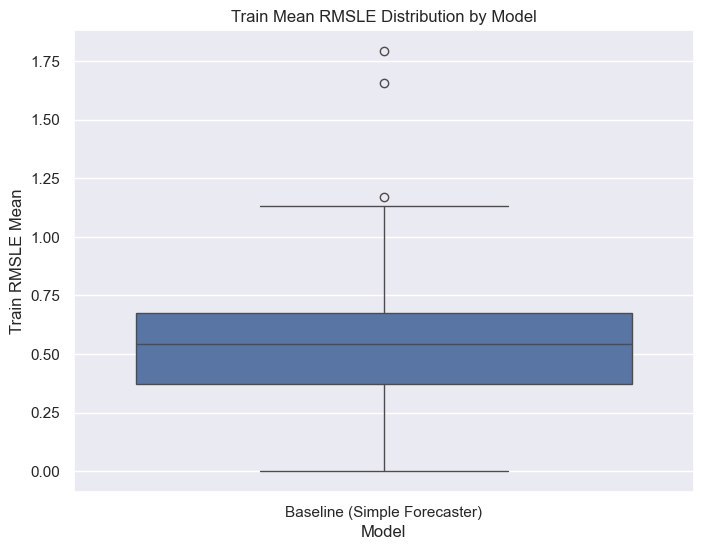

In [105]:
# Train set mean
plt.rcParams['figure.figsize'] = (8, 6)

sns.boxplot(
    df_metrics,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

print(f"Mean Train RMSLE: {df_metrics['train_rmsle_mean'].mean():.4f}")

plt.show()

Mean Test RMSLE: 0.5124


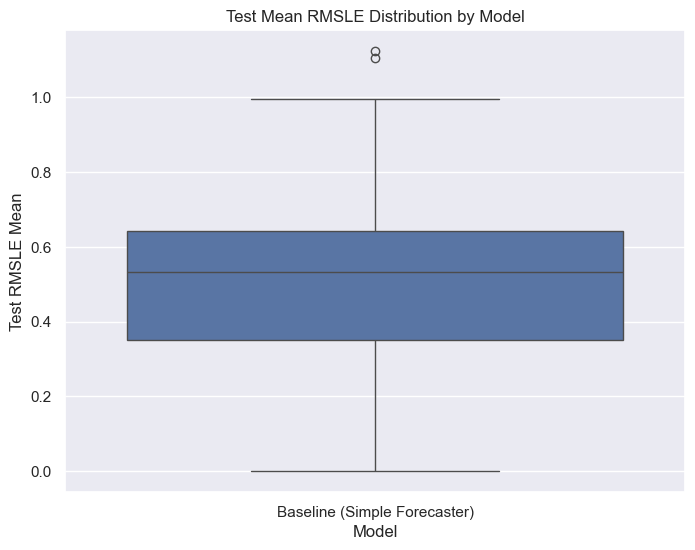

Mean Train RMSLE Std: 0.1401


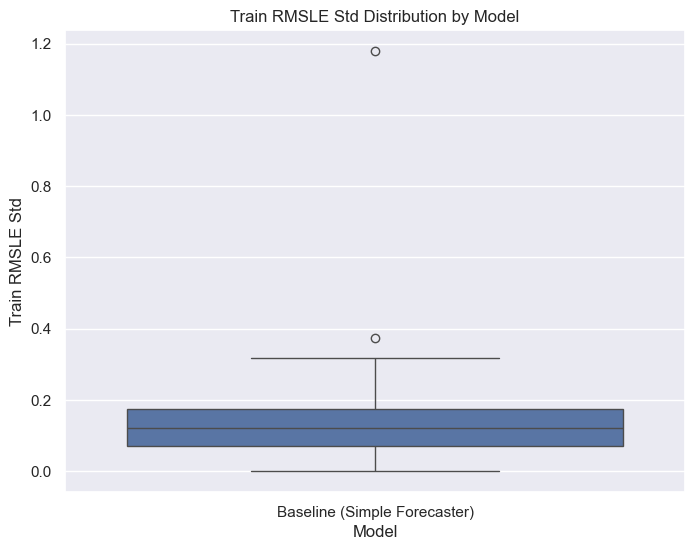

Mean Test RMSLE Std: 0.1592


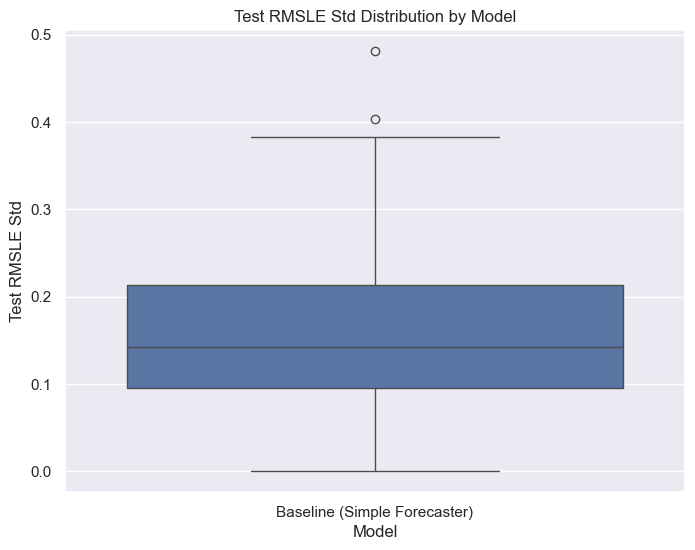

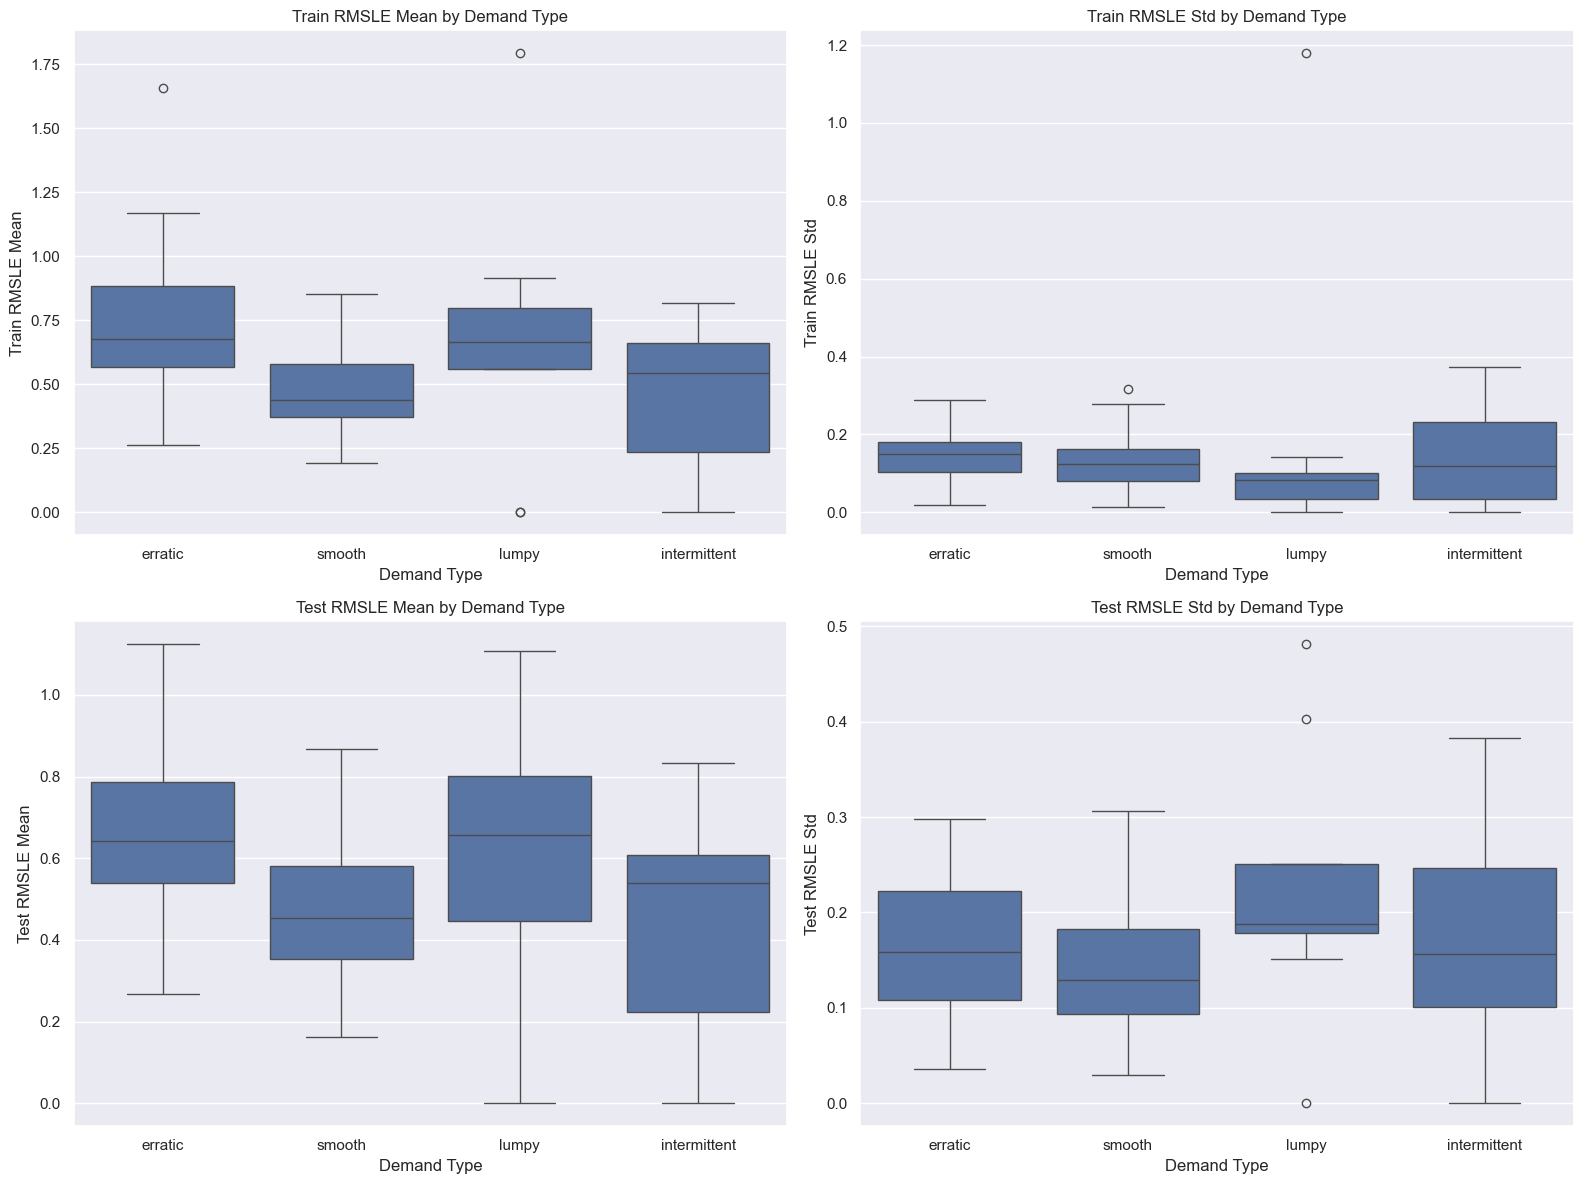

In [106]:
# Test set mean
plt.figure(figsize=(8, 6))

sns.boxplot(
    df_metrics,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

print(f"Mean Test RMSLE: {df_metrics['test_rmsle_mean'].mean():.4f}")

plt.show()

# Train set std
plt.figure(figsize=(8, 6))

sns.boxplot(
    df_metrics,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Std')
plt.title('Train RMSLE Std Distribution by Model')

print(f"Mean Train RMSLE Std: {df_metrics['train_rmsle_std'].mean():.4f}")

plt.show()

# Test set std
plt.figure(figsize=(8, 6))

sns.boxplot(
    df_metrics,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Test RMSLE Std Distribution by Model')

print(f"Mean Test RMSLE Std: {df_metrics['test_rmsle_std'].mean():.4f}")

plt.show()

# Analysis by demand type
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Train RMSLE Mean by Demand Type
sns.boxplot(data=df_metrics, x='demand_type', y='train_rmsle_mean', ax=axes[0, 0])
axes[0, 0].set_title('Train RMSLE Mean by Demand Type')
axes[0, 0].set_xlabel('Demand Type')
axes[0, 0].set_ylabel('Train RMSLE Mean')

# Train RMSLE Std by Demand Type
sns.boxplot(data=df_metrics, x='demand_type', y='train_rmsle_std', ax=axes[0, 1])
axes[0, 1].set_title('Train RMSLE Std by Demand Type')
axes[0, 1].set_xlabel('Demand Type')
axes[0, 1].set_ylabel('Train RMSLE Std')

# Test RMSLE Mean by Demand Type
sns.boxplot(data=df_metrics, x='demand_type', y='test_rmsle_mean', ax=axes[1, 0])
axes[1, 0].set_title('Test RMSLE Mean by Demand Type')
axes[1, 0].set_xlabel('Demand Type')
axes[1, 0].set_ylabel('Test RMSLE Mean')

# Test RMSLE Std by Demand Type
sns.boxplot(data=df_metrics, x='demand_type', y='test_rmsle_std', ax=axes[1, 1])
axes[1, 1].set_title('Test RMSLE Std by Demand Type')
axes[1, 1].set_xlabel('Demand Type')
axes[1, 1].set_ylabel('Test RMSLE Std')

plt.tight_layout()
plt.show()